<a href="https://colab.research.google.com/github/Ademola-Olorunnisola/Nonlinear_and_Data_Driven_Estimation/blob/main/Ademola_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from scipy.integrate import odeint
import scipy.optimize

import sympy as sp

import pandas as pd
import pandas

import copy
import os

In [24]:
try:
    import casadi
except:
    !pip install casadi
    import casadi

try:
    import do_mpc
except:
    !pip install do_mpc
    import do_mpc

try:
    import pybounds
except:
    #!pip install pybounds
    !pip install git+https://github.com/vanbreugel-lab/pybounds
    import pybounds

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 5.9 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/do_mpc/sysid/__init__.py:15: UserWarning: The ONNX feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The ONNX feature is not available. Please install the full version of do-mpc to access this feature.')
/usr/local/lib/python3.12/dist-packages/do_mpc/opcua/__init__.py:14: UserWarning: The opcua feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The opcua feature is not available. Please install the full version of do-mpc to access this feature.')


  Cloning https://github.com/vanbreugel-lab/pybounds to /tmp/pip-req-build-7ofhrd53
  Running command git clone --filter=blob:none --quiet https://github.com/vanbreugel-lab/pybounds /tmp/pip-req-build-7ofhrd53
  Resolved https://github.com/vanbreugel-lab/pybounds to commit b847eb839f75308ed8ba402f0e3356f6148d465e
  Preparing metadata (setup.py) ... done
  Created wheel for pybounds: filename=pybounds-0.0.13-py3-none-any.whl size=19568 sha256=7376d5fde8985478564d506747f0b071ea756645869ba3fe0f3fd791c8cbfbee
  Stored in directory: /tmp/pip-ephem-wheel-cache-wyitr4em/wheels/cb/f8/fb/ff1887f9a2f35c3edad7b1acb7da69437c1fd8d885a800578d
Successfully built pybounds


In [25]:
try:
    from keras_visualizer import visualizer
except:
    !pip install keras-visualizer
    from keras_visualizer import visualizer

In [26]:
import tensorflow as tf
from tensorflow.python.client import device_lib
import keras
from IPython.display import display, Image

Fetching from: 
<Response [200]>


/content/ademola_training_data.py:287: FutureWarning: Starting with pandas version 3.0 all arguments of to_hdf except for the argument 'path_or_buf' will be keyword-only.
  df_trimmed.to_hdf(fname, 'trajec')


Generated trajectory 1/10
Generated trajectory 2/10
Generated trajectory 3/10
Generated trajectory 4/10
Generated trajectory 5/10
Generated trajectory 6/10
Generated trajectory 7/10
Generated trajectory 8/10
Generated trajectory 9/10
Generated trajectory 10/10


/content/ademola_training_data.py:287: FutureWarning: Starting with pandas version 3.0 all arguments of to_hdf except for the argument 'path_or_buf' will be keyword-only.
  df_trimmed.to_hdf(fname, 'trajec')


Number of trajectories: 10


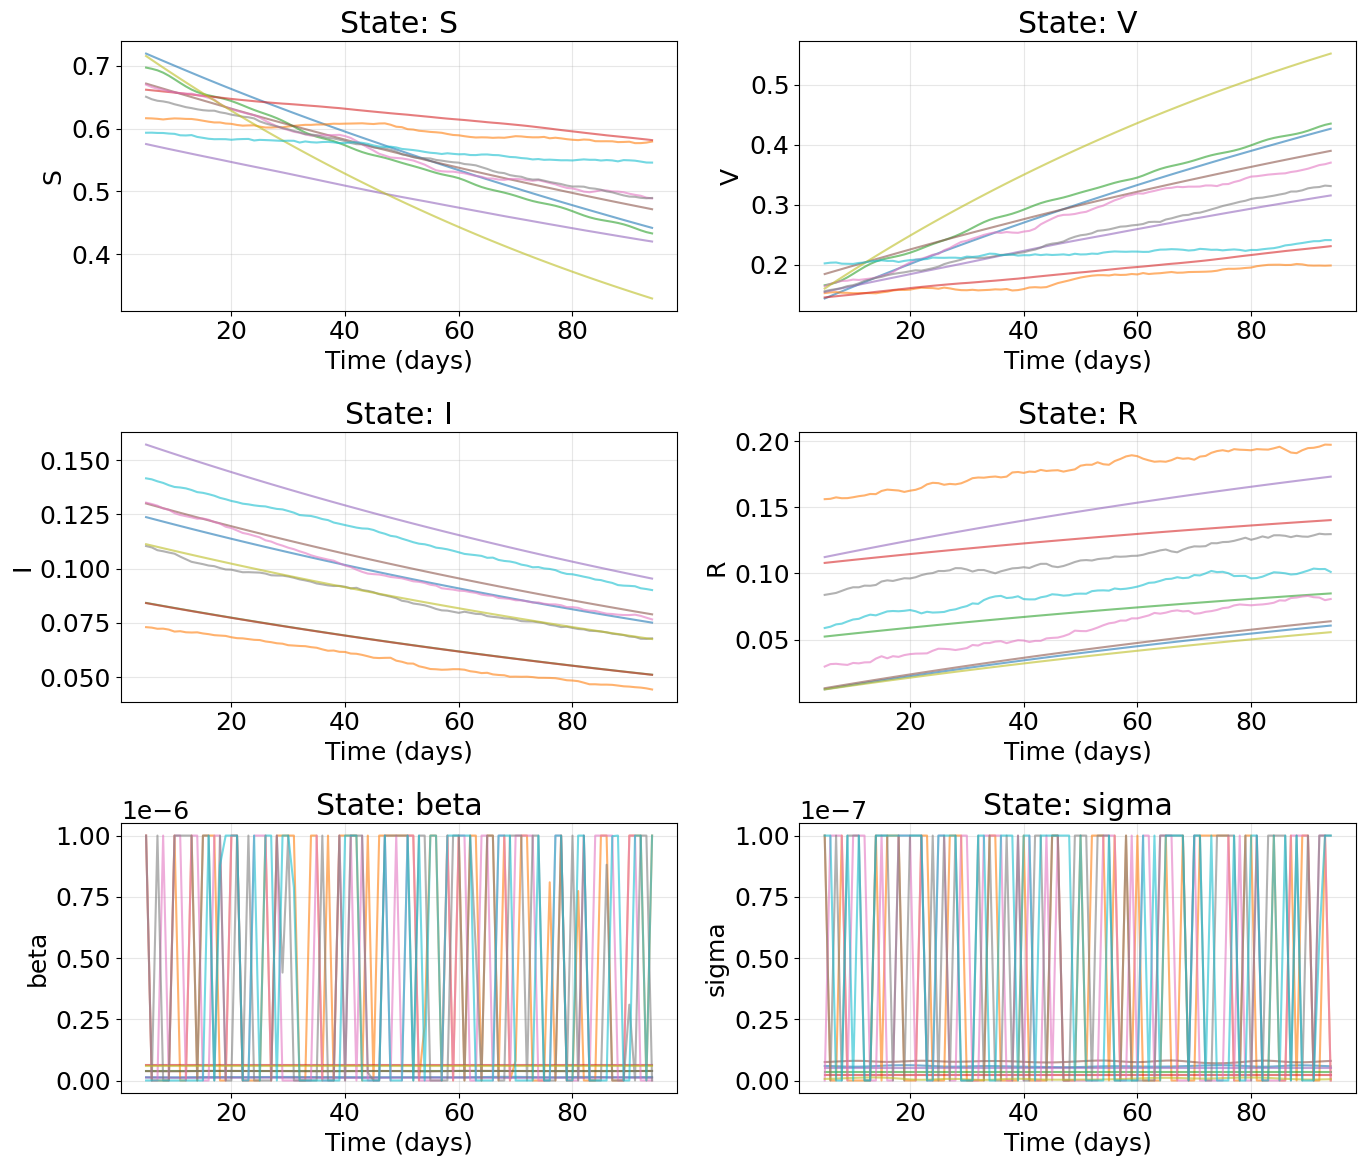

/content/ademola_training_data.py:422: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


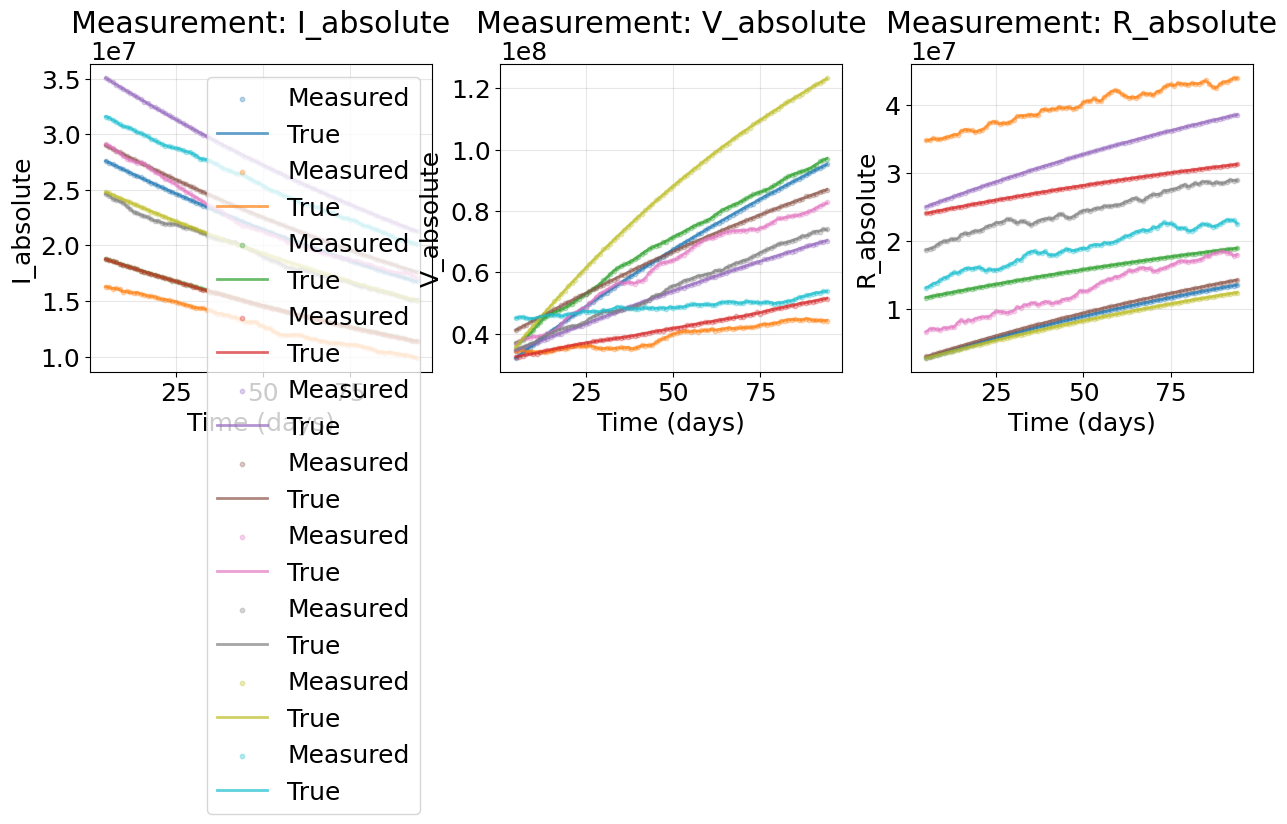


Training data generation complete!
Data saved in: tb_trajectories/
Total trajectories: 10


In [30]:
import sys
import requests
import importlib

def import_local_or_github(package_name, function_name=None, directory=None, giturl=None):
    # Import functions directly from github
    # Important: note that we use raw.githubusercontent.com, not github.com

    try: # to find the file locally
        if directory is not None:
            if directory not in sys.path:
                sys.path.append(directory)

        package = importlib.import_module(package_name)
        if function_name is not None:
            function = getattr(package, function_name)
            return function
        else:
            return package

    except: # get the file from github
        if giturl is None:
            giturl = 'https://raw.githubusercontent.com/Ademola-Olorunnisola/Nonlinear_and_Data_Driven_Estimation/main/Utility/' + str(package_name) + '.py'

        r = requests.get(giturl)
        print('Fetching from: ')
        print(r)

        # Store the file to the colab working directory
        with open(package_name+'.py', 'w') as f:
            f.write(r.text)
        f.close()

        # import the function we want from that file
        package = importlib.import_module(package_name)
        if function_name is not None:
            function = getattr(package , function_name)
            return function
        else:
            return package

tb_simulations = import_local_or_github('tb_simulations', directory='../Utility')
plot_tme = import_local_or_github('plot_utility', 'plot_tme', directory='../Utility')
ademola_training_data = import_local_or_github('ademola_training_data', directory='../Utility')

In [31]:
def collect_offset_rows(df, states=None, controls=None, outputs=None,
                        state_offsets=None, control_offsets=None, output_offsets=None):
    """ Takes a pandas data frame with n rows and creates an augmented data frame that collects
        rows at specified offsets for different column types (states, controls, outputs).

        Inputs
            df: pandas data frame
            states: list of column names to treat as states
            controls: list of column names to treat as controls
            outputs: list of column names to treat as outputs
            state_offsets: list of integer offsets for state columns (default: [-1])
            control_offsets: list of integer offsets for control columns (default: [-1])
            output_offsets: list of integer offsets for output columns (default: [0])

            Offset interpretation:
                - Negative values look backward (e.g., -1 is previous row, -2 is two rows back)
                - Zero includes current row
                - Positive values look forward (e.g., 1 is next row, 2 is two rows ahead)

        Outputs
            df_aug: augmented pandas data frame.
                    Columns are organized by type and offset:
                    - First all state columns (grouped by offset)
                    - Then all control columns (grouped by offset)
                    - Finally all output columns (grouped by offset)
                    New columns are named: old_name_offset_N (e.g., 'x_offset_-1', 'u_offset_0')
                    Only rows where all offsets are valid are included.
    """
    import pandas as pd
    import numpy as np
    df = df.reset_index(drop=True)

    # Set defaults
    if state_offsets is None:
        state_offsets = [-1]
    if control_offsets is None:
        control_offsets = [-1]
    if output_offsets is None:
        output_offsets = [0]

    # Collect all columns and offsets to determine valid row range
    all_columns = []
    all_offsets = []

    column_groups = []
    if states is not None and len(states) > 0:
        all_columns.extend(states)
        all_offsets.extend(state_offsets)
        column_groups.append(('states', states, state_offsets))

    if controls is not None and len(controls) > 0:
        all_columns.extend(controls)
        all_offsets.extend(control_offsets)
        column_groups.append(('controls', controls, control_offsets))

    if outputs is not None and len(outputs) > 0:
        all_columns.extend(outputs)
        all_offsets.extend(output_offsets)
        column_groups.append(('outputs', outputs, output_offsets))

    if len(all_columns) == 0:
        raise ValueError("At least one of states, controls, or outputs must be specified")

    # Determine valid row range
    min_offset = min(all_offsets)
    max_offset = max(all_offsets)

    n_row = df.shape[0]

    # Valid rows are those where all offsets point to existing rows
    start_row = max(0, -min_offset)
    end_row = min(n_row, n_row - max_offset)
    n_row_train = end_row - start_row

    if n_row_train <= 0:
        raise ValueError(f"No valid rows with given offsets. DataFrame has {n_row} rows, "
                        f"but offsets range from {min_offset} to {max_offset}")

    # Build augmented dataframe by processing each column group
    df_aug_parts = []

    for group_name, columns, offsets in column_groups:
        # For each offset in this group
        for offset in offsets:
            source_indices = np.arange(start_row, end_row) + offset

            # For each column with this offset
            for col in columns:
                data = df.loc[source_indices, col].reset_index(drop=True)
                col_name = f'{col}_offset_{offset}'
                df_aug_parts.append(pd.DataFrame({col_name: data}))

    # Combine all parts
    df_aug = pd.concat(df_aug_parts, axis=1)

    return df_aug

# Download, load, and clean data as in Lesson 11.B

In [33]:
# Load all trajectories from the directory
directory = 'tb_trajectories'
all_fnames = [f for f in os.listdir(directory) if f.endswith('.hdf')]

traj_list = []
for fname in all_fnames:
    fpath = os.path.join(directory, fname)
    trajec = pd.read_hdf(fpath)
    traj_list.append(trajec)

print(f'Number of trajectories loaded: {len(traj_list)}')
print(f'First trajectory shape: {traj_list[0].shape}')
print(f'Columns: {list(traj_list[0].columns)}')

Number of trajectories loaded: 10
First trajectory shape: (90, 13)
Columns: ['time', 'objid', 'S', 'V', 'I', 'R', 'beta', 'sigma', 'alpha', 'kappa', 'I_absolute', 'V_absolute', 'R_absolute']


In [34]:
def add_noise_to_trajectory_data(traj_list, noise_std):
    exclude_columns = ['time', 'objid']  # don't add noise to time or the objid!
    noise_distribution = scipy.stats.norm(0, noise_std)

    for i, trajec in enumerate(traj_list):
        for col in trajec.keys():
            if col not in exclude_columns:
                trajec[col] += noise_distribution.rvs(trajec.shape[0])
                traj_list[i] = trajec

    return traj_list

# Add small additional noise to make training more robust
noise_std = 0.0  # Set to 0 for now since measurements already have noise
traj_list = add_noise_to_trajectory_data(traj_list, noise_std)

print("Noise added to trajectories")

Noise added to trajectories


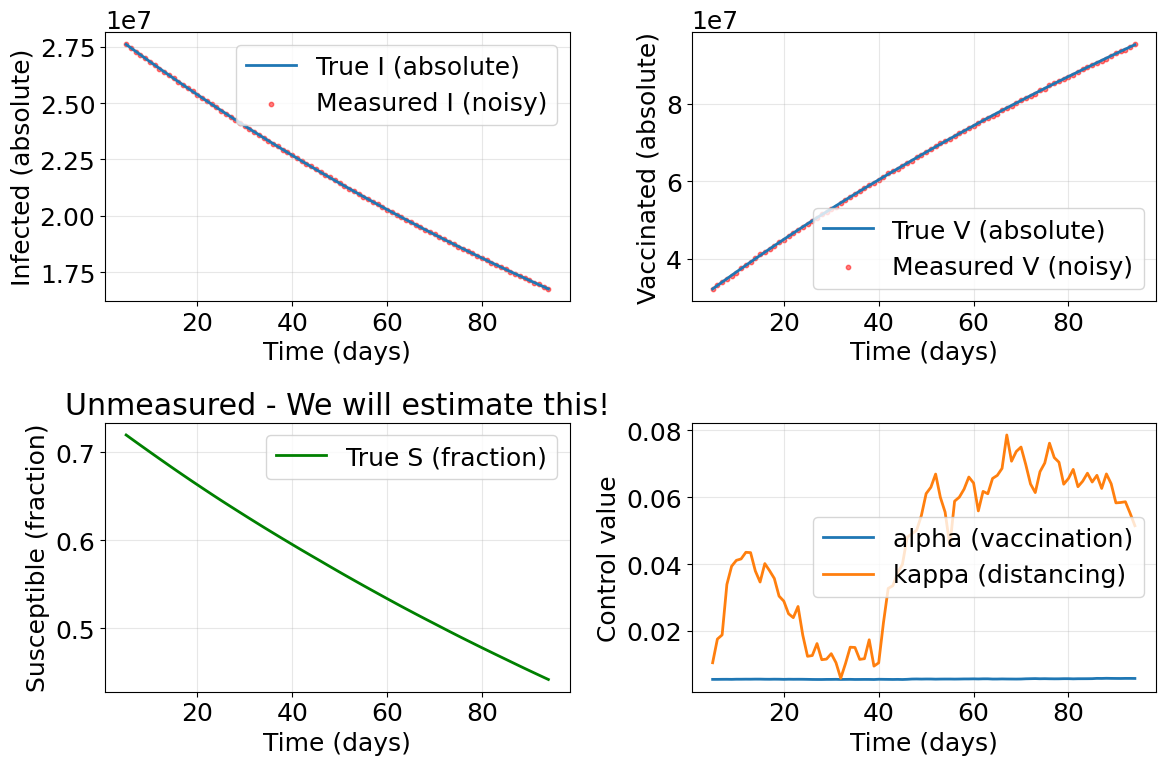

In [35]:
# Pick a trajectory to visualize
i = 0  # Look at the first trajectory
traj = traj_list[i]

# Plot the infected population over time
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Plot I (infected) - true state vs noisy measurement
axes[0, 0].plot(traj.time, traj.I * 223000000, label='True I (absolute)', linewidth=2)
axes[0, 0].scatter(traj.time, traj.I_absolute, label='Measured I (noisy)', s=10, alpha=0.5, color='red')
axes[0, 0].set_xlabel('Time (days)')
axes[0, 0].set_ylabel('Infected (absolute)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot V (vaccinated) - true state vs noisy measurement
axes[0, 1].plot(traj.time, traj.V * 223000000, label='True V (absolute)', linewidth=2)
axes[0, 1].scatter(traj.time, traj.V_absolute, label='Measured V (noisy)', s=10, alpha=0.5, color='red')
axes[0, 1].set_xlabel('Time (days)')
axes[0, 1].set_ylabel('Vaccinated (absolute)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot S (susceptible) - this is what we want to ESTIMATE
axes[1, 0].plot(traj.time, traj.S, label='True S (fraction)', linewidth=2, color='green')
axes[1, 0].set_xlabel('Time (days)')
axes[1, 0].set_ylabel('Susceptible (fraction)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_title('Unmeasured - We will estimate this!')

# Plot controls
axes[1, 1].plot(traj.time, traj.alpha, label='alpha (vaccination)', linewidth=2)
axes[1, 1].plot(traj.time, traj.kappa, label='kappa (distancing)', linewidth=2)
axes[1, 1].set_xlabel('Time (days)')
axes[1, 1].set_ylabel('Control value')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#Define inputs and outputs for the ANN

In [38]:
# Output: what we want to ESTIMATE (unmeasured states)
output_names = ['S', 'beta', 'sigma']

# Inputs: what we can MEASURE (noisy measurements + controls)
input_names = ['I_absolute', 'V_absolute', 'R_absolute', 'alpha', 'kappa']

# Time window: how many past time steps to use
time_window = 10  # Use past 10 days of measurements

# Construct input offsets (looking backward in time)
input_offsets = np.arange(time_window) * -1
print('Input offsets (negative = past):', input_offsets)

# We only need to estimate states at the current time
output_offsets = [0]

print(f'\nInputs: {input_names}')
print(f'Outputs: {output_names}')
print(f'Time window: {time_window} days')

Input offsets (negative = past): [ 0 -1 -2 -3 -4 -5 -6 -7 -8 -9]

Inputs: ['I_absolute', 'V_absolute', 'R_absolute', 'alpha', 'kappa']
Outputs: ['S', 'beta', 'sigma']
Time window: 10 days


# Create augmented training data with time windows

In [39]:
# Ignore the first and last few frames to prevent artifacts
trim_edges = 5

# Build augmented trajectory for each trajectory in the list
traj_augment_list = []
for traj in traj_list:
    traj_augment = collect_offset_rows(traj[trim_edges:-1*trim_edges],
                                       states=input_names,
                                       controls=None,
                                       outputs=output_names,
                                       state_offsets=input_offsets,
                                       control_offsets=None,
                                       output_offsets=output_offsets)

    traj_augment_list.append(traj_augment)

# Combine all trajectories into a single data frame
traj_augment_all = pd.concat(traj_augment_list, ignore_index=True)

print(f'Total training samples: {traj_augment_all.shape[0]}')
print(f'Total features: {traj_augment_all.shape[1]}')
print(f'\nFirst few column names:')
print(list(traj_augment_all.columns[:10]))

Total training samples: 710
Total features: 53

First few column names:
['I_absolute_offset_0', 'V_absolute_offset_0', 'R_absolute_offset_0', 'alpha_offset_0', 'kappa_offset_0', 'I_absolute_offset_-1', 'V_absolute_offset_-1', 'R_absolute_offset_-1', 'alpha_offset_-1', 'kappa_offset_-1']


#Separate inputs (X) and outputs (Y)

In [40]:
# Calculate dimensions
n_input = len(input_names) * time_window
n_output = len(output_names)

print(f'Number of inputs: {n_input}')
print(f'Number of outputs: {n_output}')

# Input data (X): first n_input columns
X = traj_augment_all.iloc[:, 0:n_input]
print(f'\nX shape: {X.shape}')
print('X columns (first 5):', list(X.columns[:5]))

# Output data (Y): remaining columns
Y = traj_augment_all.iloc[:, n_input:]
print(f'\nY shape: {Y.shape}')
print('Y columns:', list(Y.columns))

# Show a sample
print('\n--- Sample training example ---')
print('First input row:', X.iloc[0].values[:5], '...')
print('First output row:', Y.iloc[0].values)

Number of inputs: 50
Number of outputs: 3

X shape: (710, 50)
X columns (first 5): ['I_absolute_offset_0', 'V_absolute_offset_0', 'R_absolute_offset_0', 'alpha_offset_0', 'kappa_offset_0']

Y shape: (710, 3)
Y columns: ['S_offset_0', 'beta_offset_0', 'sigma_offset_0']

--- Sample training example ---
First input row: [2.55158679e+07 4.41563031e+07 4.85390595e+06 5.52778879e-03
 3.04049519e-02] ...
First output row: [6.66790131e-01 1.39907417e-08 6.23600125e-09]


# Define the neural network architecture

In [42]:
# Define model architecture
input_architecture = [
    {'core_input_dim': n_input},
]

core_architecture = [
    {'units': 64, 'activation': 'tanh'},
    {'units': 64, 'activation': 'tanh'},
    {'units': 32, 'activation': 'tanh'},
    {'units': n_output, 'activation': 'linear'}
]

def build_model(input_architecture, core_architecture):
    model = keras.models.Sequential()  # Sequential model (layers stacked one after another)
    n_input = input_architecture[0]['core_input_dim']

    for i, layer in enumerate(core_architecture):
        if i == 0:
            model.add(keras.layers.Dense(layer['units'],
                            input_dim=n_input,
                            activation=layer['activation']))
        else:
            model.add(keras.layers.Dense(layer['units'],
                            activation=layer['activation']))
    return model

model = build_model(input_architecture, core_architecture)

print('Neural network architecture:')
print(model.summary())


Neural network architecture:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,603 (37.51 KB)

 Trainable params: 9,603 (37.51 KB)

 Non-trainable params: 0 (0.00 B)

None


#Compile and visualize the model

Model compiled successfully!



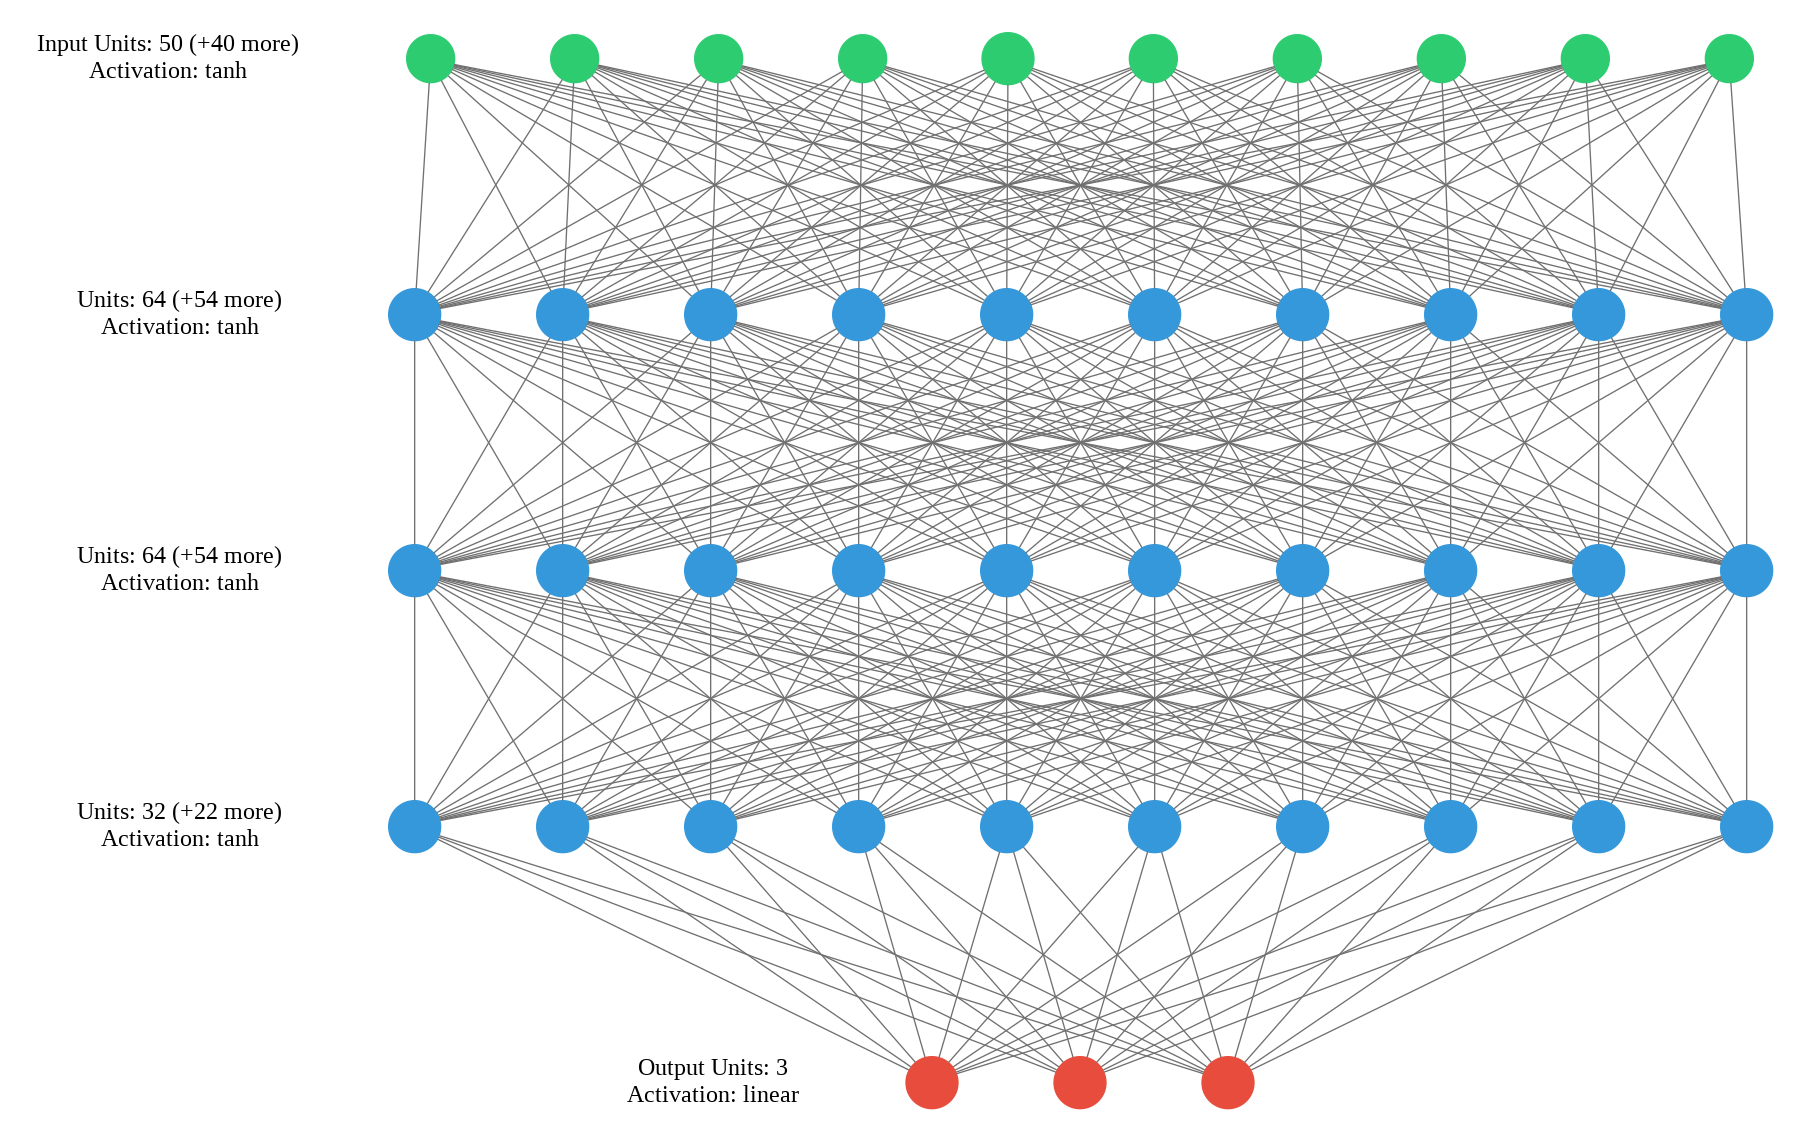

Model visualization saved as graph.png


In [43]:
# Compile the model
model.compile(loss='mean_squared_error',  # MSE loss for regression
              optimizer='adam',  # Adam optimizer (adaptive learning rate)
              metrics=['mean_absolute_error'])  # Also track MAE

print('Model compiled successfully!\n')

# Visualize the architecture
try:
    visualizer(model, file_format='png', view=False)
    display(Image(filename='graph.png'))
    print('Model visualization saved as graph.png')
except:
    print('Could not visualize model (visualizer may not be available)')